# 1. Roteiro lógico da análise
Raciocínio Lógico em etapas:
1. **Carregar dados**: importar os CSVs de crimes e de delegacias.
2. **Preparar e cruzar**: unir as bases pela chave da delegacia (`cisp` ↔ `codDP`).
3. **Tratar dados**: converter colunas numéricas e lidar com valores ausentes.
4. **Descrever estatisticamente**: calcular média, mediana, dispersão e assimetria.
5. **Visualizar**: usar gráficos para comparar regiões, DPs e identificar outliers.
6. **Concluir para o negócio**: interpretar picos, anomalias e implicações de risco.

In [1]:
# Raio-X estatístico de roubos em via pública (RJ)
# **Contexto:** análise dos crimes de oportunidade nas ruas para seguros de smartphones.

# **Objetivos:**
# - Cruzar delegacias (08.DP.csv) com histórico criminal (03.BaseDPEvolucaoMensalCisp.csv).
# - Mapear zonas vermelhas (anomalias) de 'roubo_celular' e 'roubo_transeunte'.
# - Medir correlação entre roubos de celular e roubos a pedestres em via pública.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from scipy.stats import pearsonr

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Arquivos (mesma pasta do notebook)
arquivo_dp = "08.DP.csv"
arquivo_crimes = "03.BaseDPEvolucaoMensalCisp.csv"

# Leitura das bases (estrutura baseada em 09.analise.py)
df_crimes = pd.read_csv(arquivo_crimes, sep=";", encoding="iso-8859-1")
df_dp = pd.read_csv(arquivo_dp, sep=",", encoding="utf-8")

display(df_dp.info())
display(df_crimes.info())
display(df_dp.head())
display(df_crimes.head())

<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   codDP     137 non-null    int64
 1   nome      137 non-null    str  
 2   endereco  137 non-null    str  
dtypes: int64(1), str(2)
memory usage: 3.3 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        34848 non-null  int64  
 1   mes                         34848 non-null  int64  
 2   ano                         34848 non-null  int64  
 3   mes_ano                     34848 non-null  str    
 4   aisp                        34848 non-null  int64  
 5   risp                        34848 non-null  int64  
 6   munic                       34848 non-null  str    
 7   mcirc                       34848 non-null  int64  
 8   regiao                      34848 non-null  str    
 9   hom_doloso                  34848 non-null  int64  
 10  lesao_corp_morte            34848 non-null  int64  
 11  latrocinio                  34848 non-null  int64  
 12  cvli                        34848 non-null  int64  
 13  hom_por_interv_policial     34848 non-null

None

,codDP,nome,endereco
0,1,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."


,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,estupro,hom_culposo,lesao_corp_culposa,roubo_transeunte,roubo_celular,roubo_em_coletivo,roubo_rua,roubo_veiculo,roubo_carga,roubo_comercio,roubo_residencia,roubo_banco,roubo_cx_eletronico,roubo_conducao_saque,roubo_apos_saque,roubo_bicicleta,outros_roubos,total_roubos,furto_veiculos,furto_transeunte,furto_coletivo,furto_celular,furto_bicicleta,outros_furtos,total_furtos,sequestro,extorsao,sequestro_relampago,estelionato,apreensao_drogas,posse_drogas,trafico_drogas,apreensao_drogas_sem_autor,recuperacao_veiculos,apf,aaapai,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,0,0,0,0,0,1,40,0,1,15,26,32,8,66,5,1,14,0,0,0.0,0,10,NaN,4,100,12,30,0,37,NaN,90,169,0,1,0,69,1,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,0,0,3,0,3,0,47,1,4,35,25,14,12,51,9,1,5,0,0,1.0,1,3,NaN,11,82,9,42,5,23,NaN,36,115,0,1,0,1,35,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,0,0,3,0,3,1,73,2,1,19,26,34,4,64,11,5,10,1,2,0.0,2,4,NaN,24,123,28,42,2,47,NaN,97,216,0,0,0,37,4,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,0,0,6,0,6,2,43,2,1,20,14,20,22,56,27,6,10,0,0,0.0,0,6,NaN,38,143,17,4,0,8,NaN,61,90,0,0,0,8,20,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,0,0,4,0,4,2,18,2,0,2,4,1,0,5,23,1,0,2,0,0.0,0,1,NaN,23,55,12,1,0,1,NaN,21,35,0,0,0,4,3,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,10,1,3,0,0,0,147,3


## 2. Preparação e cruzamento das bases
Identificar colunas-chave, preparar variáveis de crime e cruzar com a base de delegacias.

In [17]:
# 1) Preparação e merge de dados (baseado em 09.analise.py)
# chaves esperadas: crimes.cisp e dp.codDP
try:

    dados = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv',sep=';', encoding='iso-8859-1')
    df_comDP = df_crimes.merge(df_dp, left_on='cisp', right_on='codDP', how='left')
    df_roubo_celular = df_comDP[['cisp', 'nome', 'roubo_celular', 'regiao', 'ano']]
    df_roubo_transeunte = df_comDP[['cisp', 'nome', 'roubo_transeunte', 'regiao', 'ano']]
        
except Exception as e:
    print(f'Erro ao obter dados: {e}')


# Merge entre bases
    # df_agrupada_roubo_dp = df_roubo_celular.merge(df_dp, left_on="cisp", right_on=col_coddp, how="left")

    # display(df_agrupada_roubo_dp[["cisp", col_coddp]].head())
    # display(df_agrupada_roubo_dp[[c for c in ["roubo_celular", "roubo_transeunte"] if c in df_agrupada_roubo_dp.columns]].head())

## 3. Diagnóstico estatístico
Cálculo de medidas descritivas para `roubo_celular` e `roubo_transeunte`.

In [19]:
# Medidas estatísticas separadas para roubo_celular e roubo_transeunte
# A função abaixo encapsula o cálculo das métricas descritivas de uma série numérica.
def resumo_estatistico(s: pd.Series) -> pd.Series:
    # Converte para numérico e remove valores ausentes para não distorcer métricas
    # errors="coerce" transforma valores inválidos em NaN para não quebrar o cálculo
    s = pd.to_numeric(s, errors="coerce").dropna()
    # Média: valor central esperado (sensível a picos)
    media = s.mean()
    # Mediana: ponto central mais robusto a extremos
    mediana = s.median()
    # Moda: valor mais frequente, útil para padrão recorrente
    moda = s.mode().iloc[0] if not s.mode().empty else np.nan
    # Variância: dispersão ao quadrado em torno da média
    variancia = s.var(ddof=1)
    # Desvio padrão: dispersão na mesma unidade da variável
    desvio = s.std(ddof=1)
    # CV: dispersão relativa (comparável entre séries)
    cv = desvio / media if media != 0 else np.nan
    # Mínimo e máximo: limites observados
    minimo = s.min()
    maximo = s.max()
    # Amplitude: distância entre máximo e mínimo
    amplitude = maximo - minimo
    # Quartis: posição dos dados (Q1, Q2=mediana, Q3)
    q1 = s.quantile(0.25)
    q2 = mediana
    q3 = s.quantile(0.75)
    # IQR: faixa interquartil para medir dispersão central
    iqr = q3 - q1
    # Limites pelo IQR: ajudam a identificar outliers
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    # Assimetria: direção do “rabo” da distribuição
    assimetria = stats.skew(s, bias=False) if len(s) > 2 else np.nan
    # Curtose: intensidade de caudas/picos
    curtose = stats.kurtosis(s, fisher=True, bias=False) if len(s) > 3 else np.nan
    # Delta média-mediana: indica deslocamento por extremos
    delta = media - mediana
    return pd.Series({
        "media": media,
        "mediana": mediana,
        "moda": moda,
        "variancia": variancia,
        "desvio_padrao": desvio,
        "coef_var": cv,
        "min": minimo,
        "max": maximo,
        "amplitude": amplitude,
        "q1": q1,
        "q2_mediana": q2,
        "q3": q3,
        "limite_inferior_iqr": lim_inf,
        "limite_superior_iqr": lim_sup,
        "assimetria": assimetria,
        "curtose": curtose,
        "delta_media_mediana": delta,
    })

# Comparação separada
if "roubo_celular" in df_roubo_celular.columns:
# Estatísticas específicas de roubo de celular
    estat_roubo_celular = resumo_estatistico(df_roubo_celular["roubo_celular"])
    display(pd.DataFrame(estat_roubo_celular, columns=["roubo_celular"]))
else:
    print("Coluna 'roubo_celular' não encontrada.")

if "roubo_transeunte" in df_roubo_transeunte.columns:
# Estatísticas específicas de roubo a transeunte
    estat_roubo_transeunte = resumo_estatistico(df_roubo_transeunte["roubo_transeunte"])
    display(pd.DataFrame(estat_roubo_transeunte, columns=["roubo_transeunte"]))
else:
    print("Coluna 'roubo_transeunte' não encontrada.")

,roubo_celular
media,7.967487
mediana,2.000000
moda,0.000000
variancia,182.755766
desvio_padrao,13.518719
coef_var,1.696736
min,0.000000
max,205.000000
amplitude,205.000000
q1,0.000000


,roubo_transeunte
media,34.938476
mediana,11.000000
moda,0.000000
variancia,2601.650762
desvio_padrao,51.006380
coef_var,1.459891
min,0.000000
max,504.000000
amplitude,504.000000
q1,0.000000


### 3.1. Interpretação de Delta e Assimetria (visão de negócio)
- **Delta (média − mediana)** indica o quanto a média foi puxada por valores extremos.
- **Assimetria** mostra se a distribuição tem “cauda” maior para cima (positiva) ou para baixo (negativa).

**Leitura conjunta:**
- **Delta positivo + Assimetria positiva** ⇒ poucos meses muito violentos elevam a média. O comportamento é “puxado” por picos.
- **Delta negativo + Assimetria negativa** ⇒ poucos meses muito baixos reduzem a média (menos comum em crimes).
- **Delta próximo de zero + Assimetria baixa** ⇒ padrão mais estável, sem picos extremos dominando a série.

**Implicação prática:** se houver delta positivo e assimetria positiva, o risco mensal pode estar concentrado em períodos específicos; isso sugere sazonalidade de picos e necessidade de ajuste de prêmio por território, uma vez que uso de janela de tempo não faria sentido para o assegurado.

## 4. Dispersão e outliers (Boxplot)
Análise visual de dispersão e identificação de outliers para `roubo_celular` e `roubo_transeunte`.

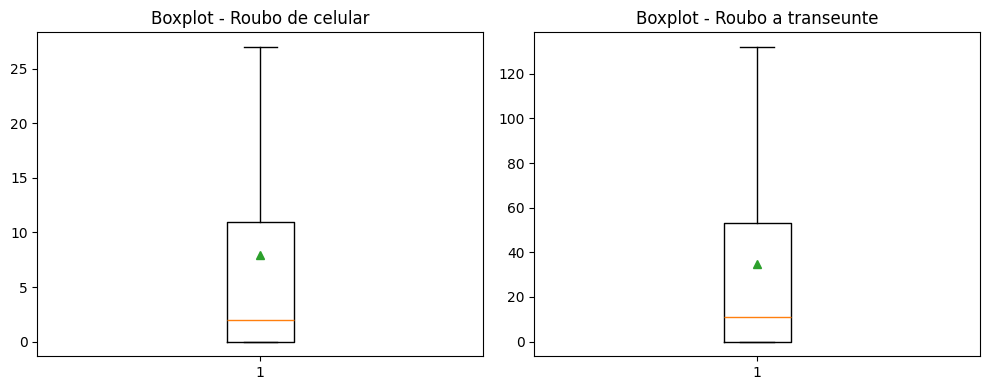

In [20]:

# Boxplots para dispersão e outliers
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# garante base disponível
try:
    df_comDP
except NameError:
    df_comDP = df_crimes.merge(df_dp, left_on="cisp", right_on="codDP", how="left")

if "roubo_celular" in df_comDP.columns:
    serie_cel = pd.to_numeric(df_comDP["roubo_celular"], errors="coerce").dropna()
    axes[0].boxplot(serie_cel, showmeans=True, showfliers=False)
    axes[0].set_title("Boxplot - Roubo de celular")
else:
    axes[0].set_title("Roubo de celular (coluna não encontrada)")

if "roubo_transeunte" in df_comDP.columns:
    serie_tran = pd.to_numeric(df_comDP["roubo_transeunte"], errors="coerce").dropna()
    axes[1].boxplot(serie_tran, showmeans=True, showfliers=False)
    axes[1].set_title("Boxplot - Roubo a transeunte")
else:
    axes[1].set_title("Roubo a transeunte (coluna não encontrada)")

plt.tight_layout()
plt.show()
# ...existing code...

## 5. Identificação de anomalias (Outliers)
Usa o limite superior do IQR para isolar outliers de `roubo_celular` e identificar a DP com mais meses fora do padrão.

In [21]:
# Outliers usando limite superior do IQR (roubo_celular)
lim_sup = None
try:
    lim_sup = float(estat_roubo_celular["limite_superior_iqr"])
except Exception as e:
    print(f"Limite superior não disponível: {e}")

# Garantir coluna numérica
try:
    df_comDP["roubo_celular"] = pd.to_numeric(df_comDP["roubo_celular"], errors="coerce").fillna(0)
except KeyError:
    print("Coluna 'roubo_celular' não encontrada em df_comDP.")

# Isolar outliers em um array numpy
if lim_sup is not None:
    df_outliers = df_comDP[df_comDP["roubo_celular"] > lim_sup].copy()
    outliers_array = df_outliers.to_numpy()
    print("Quantidade de registros outliers:", len(outliers_array))
else:
    df_outliers = df_comDP.iloc[0:0].copy()
    outliers_array = np.array([])

# DP com mais meses outliers
try:
    # Considera cada linha como um mês (base mensal)
    dp_outliers = (
        df_outliers.groupby("nome")["roubo_celular"]
        .size()
        .sort_values(ascending=False)
    )
    if not dp_outliers.empty:
        print("DP com mais meses outliers:")
        display(dp_outliers.head(1))
    else:
        print("Nenhum outlier identificado.")
except KeyError:
    print("Coluna 'nome' (DP) não encontrada para outliers.")

Quantidade de registros outliers: 2703
DP com mais meses outliers:


nome
059ª DP - Duque de Caxias    174
Name: roubo_celular, dtype: int64

## 6. Métricas principais e correlação
Resumo por região/delegacia e correlação entre `roubo_transeunte` e `roubo_celular`.

,regiao,roubo_celular,roubo_transeunte,total_roubos_rua
0,Capital,168852,679385,848237
1,Baixada Fluminense,66431,298695,365126
2,Grande Niterói,24795,157782,182577
3,Interior,17573,81674,99247


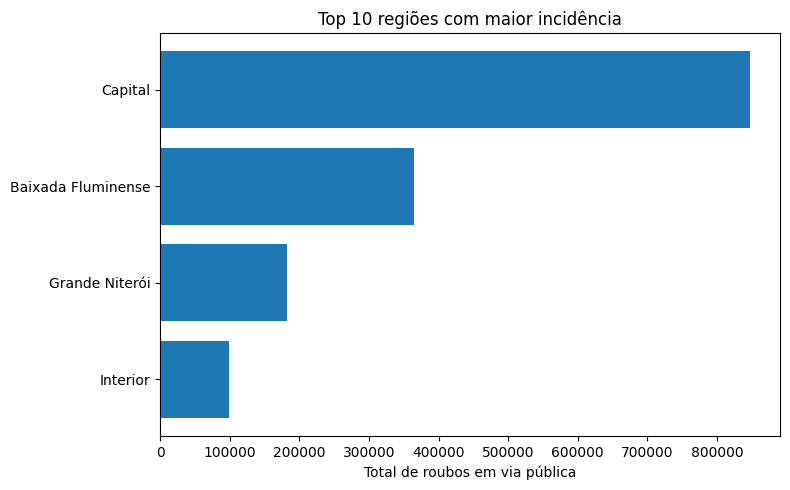

,nome,roubo_celular,roubo_transeunte,total_roubos_rua
0,059ª DP - Duque de Caxias,12319,59518,71837
1,064ª DP - São João de Meriti,9414,43262,52676
2,034ª DP - Bangu,8771,42713,51484
3,074ª DP - Alcântara,4910,35892,40802
4,029ª DP - Madureira,7814,31430,39244
5,005ª DP - Mem de Sá,6912,29650,36562
6,027ª DP - Vicente de Carvalho,6574,28495,35069
7,052ª DP - Nova Iguaçu,6262,27815,34077
8,035ª DP - Campo Grande,6332,27571,33903
9,054ª DP - Belford Roxo,5770,27521,33291


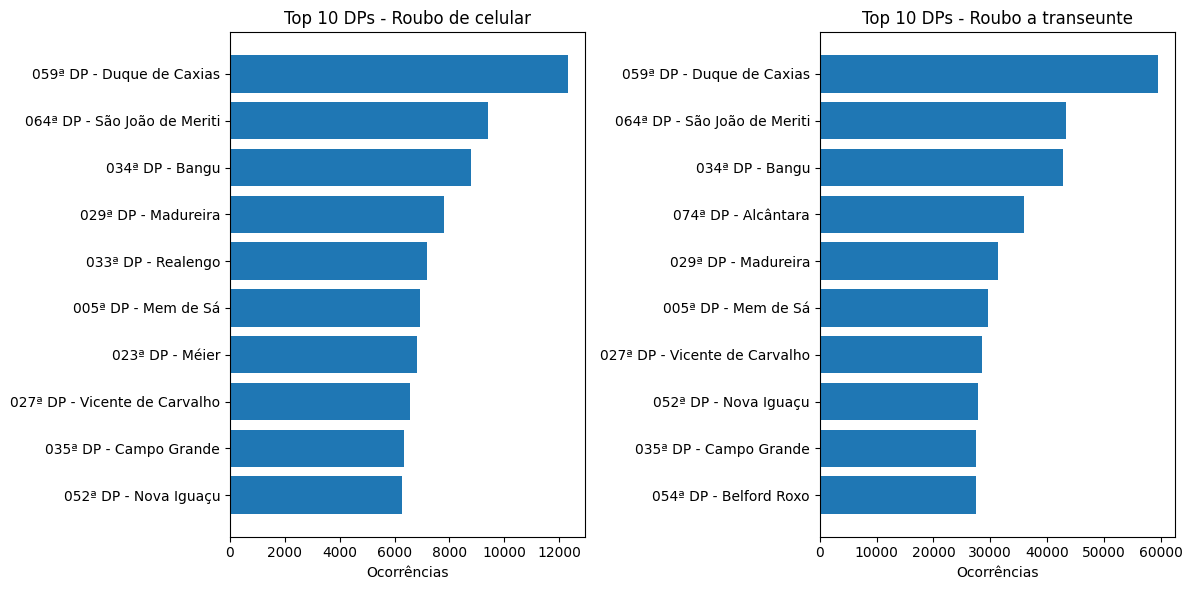

In [16]:
# Métricas principais e correlação por região e DP
try:
    df_comDP
except NameError:
    df_comDP = df_crimes.merge(df_dp, left_on="cisp", right_on="codDP", how="left")

# Garantir colunas numéricas (se existirem)
for col in ["roubo_celular", "roubo_transeunte"]:
    try:
        # errors="coerce" transforma valores inválidos em NaN para não quebrar o cálculo
        df_comDP[col] = pd.to_numeric(df_comDP[col], errors="coerce").fillna(0)
    except KeyError:
        print(f"Coluna '{col}' não encontrada.")

# Agregação por região
try:
    agg_regiao = (
        df_comDP.groupby("regiao")[["roubo_celular", "roubo_transeunte"]]
        .sum()
        # lambda d: d.sum(axis=1) soma por linha para criar o total por região
        .assign(total_roubos_rua=lambda d: d.sum(axis=1))
        .sort_values("total_roubos_rua", ascending=False)
        .reset_index()
    )
    display(agg_regiao.head(10))

    # Gráfico: top 10 regiões
    top_regiao = agg_regiao.head(10).sort_values("total_roubos_rua")
    plt.figure(figsize=(8, 5))
    plt.barh(top_regiao["regiao"].astype(str), top_regiao["total_roubos_rua"])
    plt.xlabel("Total de roubos em via pública")
    plt.title("Top 10 regiões com maior incidência")
    plt.tight_layout()
    plt.show()
except KeyError:
    print("Coluna 'regiao' não encontrada.")

# Agregação por DP (nome)
try:
    agg_dp = (
        df_comDP.groupby("nome")[["roubo_celular", "roubo_transeunte"]]
        .sum()
        # lambda d: d.sum(axis=1) soma por linha para criar o total por DP
        .assign(total_roubos_rua=lambda d: d.sum(axis=1))
        .sort_values("total_roubos_rua", ascending=False)
        .reset_index()
    )
    display(agg_dp.head(10))

    # Gráficos lado a lado por DP
    top_cel = agg_dp.sort_values("roubo_celular", ascending=False).head(10).sort_values("roubo_celular")
    top_tran = agg_dp.sort_values("roubo_transeunte", ascending=False).head(10).sort_values("roubo_transeunte")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].barh(top_cel["nome"].astype(str), top_cel["roubo_celular"])
    axes[0].set_title("Top 10 DPs - Roubo de celular")
    axes[0].set_xlabel("Ocorrências")

    axes[1].barh(top_tran["nome"].astype(str), top_tran["roubo_transeunte"])
    axes[1].set_title("Top 10 DPs - Roubo a transeunte")
    axes[1].set_xlabel("Ocorrências")

    plt.tight_layout()
    plt.show()
except KeyError:
    print("Coluna 'nome' (DP) não encontrada.")

## Storytelling (Síntese para a Seguradora)
Os dados mostram que os roubos em via pública no RJ têm **concentração territorial** (algumas DPs e regiões respondem por grande parte das ocorrências) e **comportamento assimétrico** (picos mensais elevam a média). Isso indica que o risco não é uniforme e que poucos períodos ou locais podem inflar as perdas.

**O que a informação revela:**
- Existem **zonas críticas** onde o roubo de celular e de transeunte se acumulam.
- A **assimetria positiva** sugere meses excepcionalmente violentos que distorcem a média.
- A **dispersão** e os **outliers** confirmam que o risco é concentrado em certos locais/meses.

**Métricas a priorizar para mitigar perdas e aumentar eficiência financeira:**
1. **Outliers por DP**: indica delegacias com picos recorrentes; base para ajuste de prêmio por CEP.
2. **Total por região/DP**: guia o redimensionamento de risco territorial e políticas de aceitação.
3. **Delta (média − mediana) + Assimetria**: identifica picos mensais e sazonalidade.
4. **CV (coeficiente de variação)**: mede instabilidade; maior CV exige margem técnica maior.

**Recomendação prática:**
- Reprecificar por CEP e região com base nos outliers e totais por DP.
- Introduzir ajustes sazonais quando o delta e a assimetria indicarem picos recorrentes.
- Monitorar mensalmente as DPs críticas para atualização rápida do prêmio.